# TP1 — Comparación de modelos con el protocolo de Ramiro

Se comparan los **7 modelos definidos en TP1 ramiro.ipynb** y los **10 primeros de Resultados fuerza bruta/ranking_modelos.csv**, sin ejecutar nuevamente la búsqueda masiva. Se deduplican especificaciones idénticas, incluyendo su regla de filtrado.

**Protocolo común:** split 80/20 con random_state=42; conservar el orden resultante; KFold(n_splits=5, shuffle=True, random_state=42) sobre las 540 filas del entrenamiento. Cada fold tiene 432 filas de entrenamiento antes de filtros propios del modelo y 108 de validación. Se promedian MAE y R² calculados en cada fold. La comparación se ordena por MAE creciente.

Las 135 filas reservadas no se evalúan ni intervienen en la elección del ganador de esta corrida. Sin embargo, el top 10 proviene de una selección anterior con CV sobre las 675 filas: **esta comparación es exploratoria y la reserva no es históricamente independiente de esa preselección**. Igualar el protocolo resuelve la discrepancia de métricas, pero no elimina el sesgo de haber elegido candidatos con los mismos datos.

Todos los ajustes usan LinearRegression con intercepto, sin regularización, como Ramiro. El notebook original permanece sin cambios.


In [1]:
from pathlib import Path
from itertools import combinations
import hashlib
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_absolute_error, r2_score
from IPython.display import display

SEED = 42
N_FOLDS = 5
TOP_N = 10
TOL = 1e-10
candidatas = [Path.cwd(), Path.cwd() / "LdD2026 modificacion" / "TPs" / "TP1"]
CARPETA = next((p for p in candidatas if (p / "TP1 ramiro.ipynb").exists()), None)
if CARPETA is None:
    raise FileNotFoundError("Ejecutar desde la carpeta TP1 o la raíz del proyecto.")
SALIDA = CARPETA / "Resultados comparacion protocolo Ramiro"
SALIDA.mkdir(exist_ok=True)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 30)


## 1. Datos y particiones comunes

La codificación es exactamente la de Ramiro. No se ordenan las 540 filas después del split ni se eliminan filas por faltantes. Una categoría desconocida produce un error.


In [2]:
predictores = pd.read_csv(CARPETA / "X_train.csv")
var_ind = pd.read_csv(CARPETA / "y_train.csv")["weight"]
mapas = {
    "mature": {"younger mom": 0, "mature mom": 1},
    "sex": {"female": 0, "male": 1},
    "habit": {"nonsmoker": 0, "smoker": 1},
    "marital": {"not married": 0, "married": 1},
    "whitemom": {"not white": 0, "white": 1},
}
for nombre, mapa in mapas.items():
    assert predictores[nombre].isin(mapa).all(), f"Revisar categorías: {nombre}"
    predictores[nombre + "_bin"] = predictores[nombre].map(mapa)

base9 = ["fage", "mage", "visits", "gained", "sex_bin", "habit_bin",
         "marital_bin", "whitemom_bin", "mature_bin"]
assert len(predictores) == len(var_ind) == 675
assert np.isfinite(predictores[base9].to_numpy()).all()
assert np.isfinite(var_ind.to_numpy()).all()

X_entrenamiento, X_reserva, y_entrenamiento, y_reserva = train_test_split(
    predictores, var_ind, test_size=0.20, random_state=SEED
)
particiones = list(KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED).split(X_entrenamiento))
assert len(X_entrenamiento) == 540 and len(X_reserva) == 135
assert set(X_entrenamiento.index).isdisjoint(X_reserva.index)
assert all(len(tr) == 432 and len(va) == 108 for tr, va in particiones)
assert np.array_equal(np.sort(np.concatenate([va for _, va in particiones])), np.arange(540))
print("675 filas originales; 540 para comparación; 135 reservadas sin evaluar en esta corrida.")
print("Cada fold: 432 para entrenar antes de filtros y 108 para validar.")


675 filas originales; 540 para comparación; 135 reservadas sin evaluar en esta corrida.
Cada fold: 432 para entrenar antes de filtros y 108 para validar.


## 2. Los siete modelos manuales

Se reproducen las funciones de Ramiro. El Modelo 5 cambia visitas=0 por 1 únicamente en el denominador gained/visits. El Modelo 6 usa sus seis variables y filtra weight<4 únicamente en el entrenamiento de cada fold: la validación conserva todos los casos. El Modelo 7 genera mage, gained, sus cuadrados y su producto.

Más abajo se verifica que estas funciones construyan las mismas matrices que las funciones leídas del notebook original; se cargan sólo sus definiciones de funciones y no se ejecutan sus celdas de análisis.


In [3]:
def construir_X_modelo_1(df):
    return np.array(df[["fage", "mage", "visits", "gained", "sex_bin", "habit_bin", "marital_bin", "whitemom_bin", "mature_bin"]])

def construir_X_modelo_2(df):
    return np.array(df[["mage", "visits", "gained", "sex_bin", "habit_bin", "whitemom_bin"]])

def construir_X_modelo_3(df):
    return np.array(df[["mage", "gained", "habit_bin", "whitemom_bin"]])

def construir_X_modelo_4(df):
    return np.array(df[["mage", "gained", "whitemom_bin"]])

def construir_X_modelo_5(df):
    visitas_seguras = df["visits"].replace(0.0, 1.0)
    return np.array(np.column_stack([
        df["visits"] / df["mage"],
        df["gained"],
        df["gained"] / visitas_seguras,
        df["sex_bin"] * df["gained"],
        df["habit_bin"] * df["gained"],
        df["visits"] * df["mage"],
    ]))

def construir_X_modelo_6(df):
    return np.array(df[["mage", "gained", "habit_bin", "whitemom_bin", "marital_bin", "sex_bin"]])

def construir_X_modelo_7(df):
    poly = PolynomialFeatures(degree=2, include_bias=False)
    return poly.fit_transform(df[["mage", "gained"]])

funciones_manuales = [
    construir_X_modelo_1, construir_X_modelo_2, construir_X_modelo_3,
    construir_X_modelo_4, construir_X_modelo_5, construir_X_modelo_6, construir_X_modelo_7,
]
terminos_manuales = [
    base9,
    ["mage", "visits", "gained", "sex_bin", "habit_bin", "whitemom_bin"],
    ["mage", "gained", "habit_bin", "whitemom_bin"],
    ["mage", "gained", "whitemom_bin"],
    ["visits/mage", "gained", "gained/visits_seguras", "sex_bin*gained", "habit_bin*gained", "visits*mage"],
    ["mage", "gained", "habit_bin", "whitemom_bin", "marital_bin", "sex_bin"],
    ["mage", "gained", "mage^2", "mage*gained", "gained^2"],
]

# Verificación contra las definiciones actuales del original, sin ejecutar sus análisis.
import ast
nb_original = json.loads((CARPETA / "TP1 ramiro.ipynb").read_text(encoding="utf-8"))
funciones_ast = []
for celda in nb_original["cells"]:
    if celda["cell_type"] != "code":
        continue
    texto = "".join(celda["source"])
    if "def construir_X_modelo_" in texto:
        funciones_ast.extend(n for n in ast.parse(texto).body if isinstance(n, ast.FunctionDef)
                             and n.name.startswith("construir_X_modelo_"))
assert len(funciones_ast) == 7, "Cambió el original: revisar alcance y definiciones."
referencia = {"np": np, "PolynomialFeatures": PolynomialFeatures}
exec(compile(ast.Module(body=funciones_ast, type_ignores=[]), "funciones_Ramiro", "exec"), referencia)
for numero, funcion in enumerate(funciones_manuales, 1):
    np.testing.assert_allclose(
        funcion(X_entrenamiento), referencia[f"construir_X_modelo_{numero}"](X_entrenamiento),
        atol=0, rtol=0
    )
print("Las 7 matrices coinciden exactamente con las funciones guardadas en Ramiro.")


Las 7 matrices coinciden exactamente con las funciones guardadas en Ramiro.


## 3. Top 10 y catálogo deduplicado

El ranking anterior seleccionó por MAE de CV sobre 675 observaciones. Se conserva ese puesto como información de procedencia; la nueva selección usa únicamente el MAE medio de las particiones comunes de 540 filas.

Dos especificaciones se consideran idénticas si tienen los mismos términos (independientemente del orden de sus productos) y la misma regla de filtrado. Modelos con y sin exclusión de pesos bajos son procedimientos diferentes.


In [4]:
ranking_original = pd.read_csv(CARPETA / "Resultados fuerza bruta" / "ranking_modelos.csv")
top10 = ranking_original.sort_values("ranking_mae").head(TOP_N)
assert len(top10) == 10 and 16661 in top10.modelo_id.values

def canonico(termino):
    return "*".join(sorted(termino.split("*"))) if "*" in termino else termino

modelos = []
vistos = {}
alias_a_id = {}

def registrar(nombre, origen, funcion, terminos, filtrar=False, id_bruta=None, puesto=None):
    clave = (tuple(sorted(canonico(t) for t in terminos)), bool(filtrar))
    if clave in vistos:
        mid = vistos[clave]
        modelos[mid]["alias"].append(nombre)
        alias_a_id[nombre] = mid
        return
    mid = len(modelos)
    vistos[clave] = mid
    alias_a_id[nombre] = mid
    modelos.append({
        "comparacion_id": mid, "nombre": nombre, "alias": [nombre], "origen": origen,
        "funcion": funcion, "terminos": terminos, "filtrar_weight_menor_4": filtrar,
        "id_fuerza_bruta": id_bruta, "puesto_original": puesto,
    })

for i, (funcion, terminos) in enumerate(zip(funciones_manuales, terminos_manuales), 1):
    registrar(f"Ramiro {i}", "Manual", funcion, terminos, filtrar=(i == 6))

def funcion_candidata(columnas, pares):
    def construir(df):
        bloques = [df[columnas].to_numpy()]
        bloques.extend((df[a] * df[b]).to_numpy()[:, None] for a, b in pares)
        return np.column_stack(bloques)
    return construir

for _, fila in top10.iterrows():
    columnas = fila["variables"].split(" + ")
    pares = [tuple(t.split(" × ")) for t in fila["interacciones"].split(" + ")] if pd.notna(fila["interacciones"]) else []
    terminos = columnas + [f"{a}*{b}" for a, b in pares]
    registrar(f"FB {int(fila.modelo_id)}", "Top 10 fuerza bruta",
              funcion_candidata(columnas, pares), terminos,
              id_bruta=int(fila.modelo_id), puesto=int(fila.ranking_mae))

catalogo = pd.DataFrame([{
    k: v for k, v in m.items() if k not in ("funcion", "alias", "terminos")
} | {"alias": " | ".join(m["alias"]), "terminos": " + ".join(m["terminos"]),
     "n_terminos": len(m["terminos"])} for m in modelos])
print(f"17 entradas; {len(modelos)} especificaciones únicas después de deduplicar.")
display(catalogo[["comparacion_id", "nombre", "terminos", "filtrar_weight_menor_4", "puesto_original"]])


17 entradas; 17 especificaciones únicas después de deduplicar.


,comparacion_id,nombre,terminos,filtrar_weight_menor_4,puesto_original
0,0,Ramiro 1,fage + mage + visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,False,NaN
1,1,Ramiro 2,mage + visits + gained + sex_bin + habit_bin + whitemom_bin,False,NaN
2,2,Ramiro 3,mage + gained + habit_bin + whitemom_bin,False,NaN
3,3,Ramiro 4,mage + gained + whitemom_bin,False,NaN
4,4,Ramiro 5,visits/mage + gained + gained/visits_seguras + sex_bin*gained + habit_bin*gained + visits*mage,False,NaN
5,5,Ramiro 6,mage + gained + habit_bin + whitemom_bin + marital_bin + sex_bin,True,NaN
6,6,Ramiro 7,mage + gained + mage^2 + mage*gained + gained^2,False,NaN
7,7,FB 16661,fage + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + sex_bin*marital_bin + marital_bin*whitemom_bin,False,1.0
8,8,FB 20247,visits + gained + sex_bin + marital_bin + whitemom_bin + mature_bin + visits*mature_bin + sex_bin*marital_bin,False,2.0
9,9,FB 27126,fage + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin + sex_bin*marital_bin + marital_bin*wh...,False,3.0


## 4. Evaluación en las mismas particiones

Se entrena un modelo nuevo en cada fold. No se usan predicciones sobre el entrenamiento como puntaje de selección. La variable objetivo de validación no participa en ajustes, transformaciones ni filtros.

MAE está expresado en libras. R² se calcula por fold y luego se promedia: no se concatena para calcular un único R². El desvío muestral (ddof=1) describe variación entre folds, no un intervalo de confianza.


In [5]:
registros = []
for modelo in modelos:
    for fold, (tr, va) in enumerate(particiones, 1):
        xtr, xva = X_entrenamiento.iloc[tr], X_entrenamiento.iloc[va]
        ytr, yva = y_entrenamiento.iloc[tr], y_entrenamiento.iloc[va]
        assert set(xtr.index).isdisjoint(xva.index)
        excluidos = 0
        if modelo["filtrar_weight_menor_4"]:
            mascara = ytr >= 4
            excluidos = int((~mascara).sum())
            xtr, ytr = xtr.loc[mascara], ytr.loc[mascara]
        matriz_tr = modelo["funcion"](xtr)
        matriz_va = modelo["funcion"](xva)
        assert np.isfinite(matriz_tr).all() and np.isfinite(matriz_va).all()
        reg = LinearRegression()
        reg.fit(matriz_tr, np.array(ytr))
        pred = reg.predict(matriz_va)
        registros.append({
            "comparacion_id": modelo["comparacion_id"], "nombre": modelo["nombre"], "fold": fold,
            "n_train_antes_filtro": len(tr), "n_train_efectivo": len(ytr), "n_excluidos": excluidos,
            "n_validacion": len(yva),
            "mae": mean_absolute_error(yva, pred), "r2": r2_score(yva, pred),
        })
por_fold = pd.DataFrame(registros)
resumen = por_fold.groupby("comparacion_id").agg(
    mae_promedio=("mae", "mean"), mae_desvio=("mae", "std"),
    mae_minimo=("mae", "min"), mae_maximo=("mae", "max"),
    r2_promedio=("r2", "mean"), r2_desvio=("r2", "std"),
).reset_index().merge(catalogo, on="comparacion_id")
base_id = alias_a_id["Ramiro 1"]
base = resumen.loc[resumen.comparacion_id.eq(base_id)].iloc[0]
base_folds = por_fold.loc[por_fold.comparacion_id.eq(base_id)].set_index("fold").mae
resumen["delta_mae_vs_base"] = resumen.mae_promedio - base.mae_promedio
resumen["folds_mejora_vs_base"] = [
    int((por_fold.loc[por_fold.comparacion_id.eq(mid)].set_index("fold").mae < base_folds - TOL).sum())
    for mid in resumen.comparacion_id
]
resumen = resumen.sort_values(["mae_promedio", "n_terminos", "comparacion_id"]).reset_index(drop=True)
resumen.insert(0, "puesto_comun", np.arange(1, len(resumen) + 1))
columnas_vista = ["puesto_comun", "nombre", "mae_promedio", "mae_desvio", "r2_promedio",
                  "r2_desvio", "delta_mae_vs_base", "folds_mejora_vs_base"]
display(resumen[columnas_vista].round(6))
display(por_fold.pivot(index="fold", columns="nombre", values="mae").round(5))


,puesto_comun,nombre,mae_promedio,mae_desvio,r2_promedio,r2_desvio,delta_mae_vs_base,folds_mejora_vs_base
0,1,Ramiro 6,0.910390,0.122768,0.033859,0.041509,-0.023061,4
1,2,FB 6743,0.918001,0.122259,0.004506,0.031598,-0.015450,4
2,3,FB 16661,0.919177,0.125327,0.011075,0.044674,-0.014274,4
3,4,FB 27126,0.921891,0.128257,0.012698,0.053606,-0.011559,4
4,5,FB 10210,0.922231,0.122143,0.008618,0.040988,-0.011219,4
5,6,FB 32316,0.923565,0.133681,0.003046,0.079972,-0.009885,4
6,7,FB 20630,0.923701,0.130015,0.013718,0.055923,-0.009750,4
7,8,Ramiro 4,0.924902,0.121918,0.001745,0.034397,-0.008549,3
8,9,FB 31909,0.927858,0.136689,-0.001980,0.082510,-0.005593,4
9,10,Ramiro 3,0.929768,0.127834,0.003692,0.049867,-0.003682,2


nombre,FB 10210,FB 16661,FB 20247,FB 20630,FB 25574,FB 27126,FB 28899,FB 31909,FB 32316,FB 6743,Ramiro 1,Ramiro 2,Ramiro 3,Ramiro 4,Ramiro 5,Ramiro 6,Ramiro 7
fold,,,,,,,,,,,,,,,,,
1,1.04123,1.03753,1.07004,1.02982,1.05448,1.03042,1.05716,1.04656,1.04942,1.05365,1.06084,1.06423,1.05479,1.06415,1.06985,1.06172,1.06812
2,0.96047,0.97028,0.95789,0.98214,0.94985,0.97864,0.94060,0.93166,0.92146,0.98463,0.93788,0.91558,0.95016,0.97528,0.96169,0.92725,1.02859
3,0.75366,0.75469,0.75622,0.74444,0.76410,0.74980,0.75286,0.75665,0.75593,0.75792,0.76767,0.77526,0.77342,0.76702,0.76356,0.74375,0.74201
4,1.01614,1.01451,1.02262,1.03277,1.03752,1.02816,1.06507,1.07496,1.06078,0.96913,1.04412,1.03553,1.04663,0.98680,1.00862,0.97792,0.99342
5,0.83966,0.81887,0.84580,0.82932,0.84316,0.82243,0.84030,0.82946,0.83024,0.82467,0.85674,0.85860,0.82385,0.83126,0.87217,0.84131,0.84991


## 5. Comprobaciones y resultados persistentes

Se comprueban los valores reproducidos en la investigación: base 0,9334507747050269 y ganador original 16661 con MAE 0,9191769722662467 bajo este protocolo. También se verifican los MAE redondeados de los siete modelos manuales contra las salidas guardadas de Ramiro.

Los archivos se guardan en una carpeta separada. La tabla de particiones permite reconstruir los folds mediante el número de fila del CSV original, sin reordenar los datos.


In [6]:
por_nombre = resumen.set_index("nombre")
np.testing.assert_allclose(por_nombre.loc["Ramiro 1", "mae_promedio"], 0.9334507747050269, atol=1e-10, rtol=0)
np.testing.assert_allclose(por_nombre.loc["FB 16661", "mae_promedio"], 0.9191769722662467, atol=1e-10, rtol=0)
mae_manual_guardado = [0.9335, 0.9298, 0.9298, 0.9249, 0.9352, 0.9104, 0.9364]
np.testing.assert_array_equal(
    [round(por_nombre.loc[f"Ramiro {i}", "mae_promedio"], 4) for i in range(1, 8)],
    mae_manual_guardado
)
assert len(por_fold) == len(modelos) * 5
assert not por_fold.duplicated(["comparacion_id", "fold"]).any()
assert por_fold.n_validacion.eq(108).all()
assert por_fold.loc[por_fold.nombre.ne("Ramiro 6"), "n_excluidos"].eq(0).all()

tabla_particiones = pd.DataFrame({
    "fila_original": X_entrenamiento.index.to_numpy(),
    "posicion_en_entrenamiento": np.arange(len(X_entrenamiento)),
    "fold_validacion": 0,
})
for fold, (_, va) in enumerate(particiones, 1):
    tabla_particiones.loc[va, "fold_validacion"] = fold
assert tabla_particiones.fold_validacion.value_counts().eq(108).all()
assert set(tabla_particiones.fila_original).isdisjoint(X_reserva.index)

resumen.to_csv(SALIDA / "ranking_protocolo_ramiro.csv", index=False)
por_fold.to_csv(SALIDA / "metricas_por_fold.csv", index=False)
catalogo.to_csv(SALIDA / "catalogo_modelos.csv", index=False)
tabla_particiones.to_csv(SALIDA / "particiones_comunes.csv", index=False)
fuentes = ["TP1 ramiro.ipynb", "X_train.csv", "y_train.csv", "Resultados fuerza bruta/ranking_modelos.csv"]
config = {
    "seed_split": SEED, "test_size": 0.20, "seed_folds": SEED, "n_folds": N_FOLDS,
    "n_original": len(predictores), "n_comparacion": len(X_entrenamiento), "n_reserva_sin_evaluar": len(X_reserva),
    "orden": "Orden devuelto por train_test_split; no ordenar ni resetear el orden de filas",
    "seleccion": "Menor MAE medio de 5 folds; desempate por menos términos y comparacion_id",
    "n_modelos_unicos": len(modelos), "top_n_anterior": TOP_N,
    "limitacion": "Top 10 preseleccionado anteriormente con CV675: comparación exploratoria, no evaluación independiente",
    "sha256_fuentes": {f: hashlib.sha256((CARPETA / f).read_bytes()).hexdigest() for f in fuentes},
}
(SALIDA / "configuracion.json").write_text(json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8")
print("Verificaciones correctas: 7 modelos manuales, ganador original, particiones y métricas.")
print(f"Guardados {len(modelos)} modelos y {len(por_fold)} evaluaciones por fold.")


Verificaciones correctas: 7 modelos manuales, ganador original, particiones y métricas.
Guardados 17 modelos y 85 evaluaciones por fold.


## 6. Orden bajo el protocolo común

Los puntos de cada modelo muestran sus cinco MAE; la marca negra muestra el promedio. La variación entre folds ayuda a poner en contexto diferencias pequeñas entre promedios.


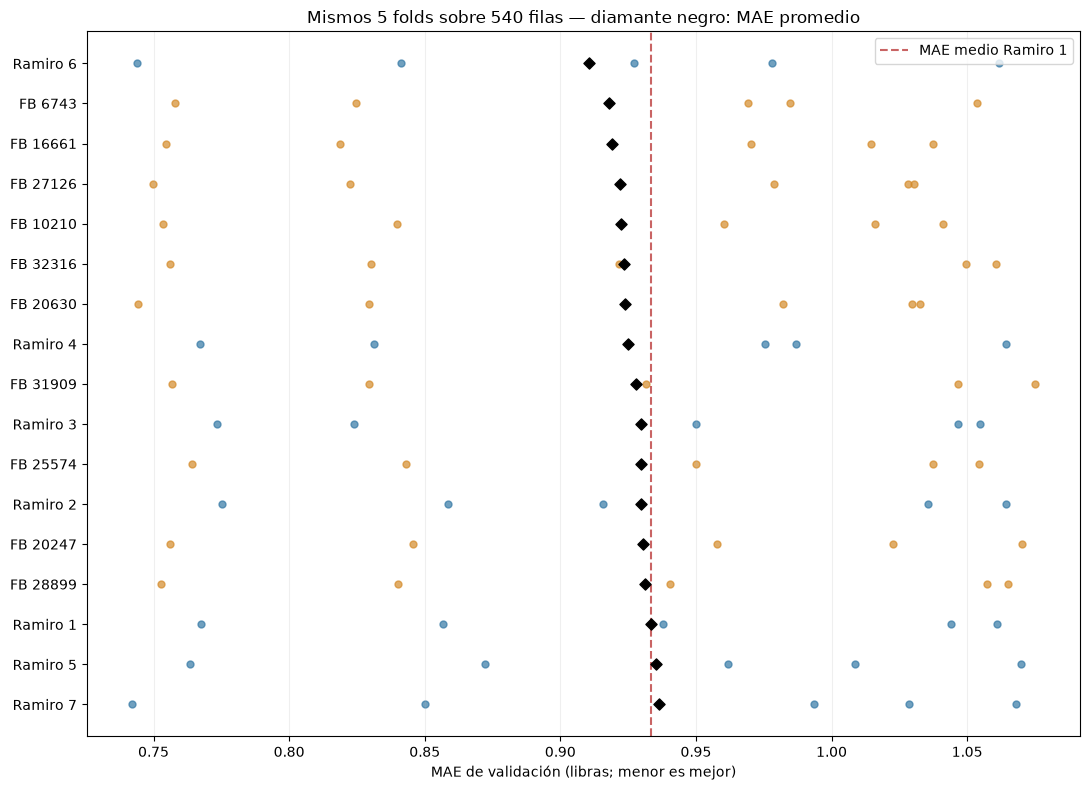

Mejor MAE entre los modelos comparados: Ramiro 6
MAE = 0.910390; desvío = 0.122768
R² medio = 0.033859; desvío = 0.041509
Términos: mage + gained + habit_bin + whitemom_bin + marital_bin + sex_bin
Filtro de entrenamiento weight >= 4: True
La selección usa el MAE: el modelo con mayor R² puede ser otro.
No se afirma que sea el mejor entre los 33.343 bajo este protocolo: aquí sólo se evaluaron los 7 manuales y el top 10 anterior.


,fold,n_train_efectivo,n_excluidos,n_validacion,mae,r2
25,1,429,3,108,1.061720,0.004331
26,2,424,8,108,0.927251,0.076666
27,3,424,8,108,0.743749,0.071596
28,4,426,6,108,0.977925,-0.018688
29,5,425,7,108,0.841306,0.035389


Resultados: G:\My Drive\W\2026-2C-Labo-de-datos\LdD2026 modificacion\TPs\TP1\Resultados comparacion protocolo Ramiro


In [7]:
fig, ax = plt.subplots(figsize=(11, 8))
for pos, fila in resumen.iterrows():
    valores = por_fold.loc[por_fold.comparacion_id.eq(fila.comparacion_id), "mae"].to_numpy()
    ax.scatter(valores, np.full(5, pos), color="#3478a5" if fila.origen == "Manual" else "#d48a29",
               alpha=0.7, s=25)
    ax.scatter(fila.mae_promedio, pos, color="black", marker="D", s=32, zorder=4)
ax.axvline(base.mae_promedio, color="firebrick", linestyle="--", alpha=0.7, label="MAE medio Ramiro 1")
ax.set_yticks(np.arange(len(resumen)), resumen.nombre)
ax.invert_yaxis()
ax.set_xlabel("MAE de validación (libras; menor es mejor)")
ax.set_title("Mismos 5 folds sobre 540 filas — diamante negro: MAE promedio")
ax.grid(axis="x", alpha=0.2)
ax.legend()
plt.tight_layout()
plt.show()

ganador = resumen.iloc[0]
print(f"Mejor MAE entre los modelos comparados: {ganador['nombre']}")
print(f"MAE = {ganador.mae_promedio:.6f}; desvío = {ganador.mae_desvio:.6f}")
print(f"R² medio = {ganador.r2_promedio:.6f}; desvío = {ganador.r2_desvio:.6f}")
print(f"Términos: {ganador.terminos}")
print(f"Filtro de entrenamiento weight >= 4: {ganador.filtrar_weight_menor_4}")
print("La selección usa el MAE: el modelo con mayor R² puede ser otro.")
print("No se afirma que sea el mejor entre los 33.343 bajo este protocolo: aquí sólo se evaluaron los 7 manuales y el top 10 anterior.")
display(por_fold.loc[por_fold.nombre.eq("Ramiro 6"), ["fold", "n_train_efectivo", "n_excluidos", "n_validacion", "mae", "r2"]].round(6))
print(f"Resultados: {SALIDA.resolve()}")
